In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("cancer_reg.csv")

In [3]:
df.head()

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,binnedinc,medianage,...,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
0,1397.0,469,164.9,489.8,61898,260131,11.2,499.748204,"(61494.5, 125635]",39.3,...,NaN,41.6,32.9,14.0,81.780529,2.594728,4.821857,1.843479,52.856076,6.118831
1,173.0,70,161.3,411.6,48127,43269,18.6,23.111234,"(48021.6, 51046.4]",33.0,...,53.8,43.6,31.1,15.3,89.228509,0.969102,2.246233,3.741352,45.372500,4.333096
2,102.0,50,174.7,349.7,49348,21026,14.6,47.560164,"(48021.6, 51046.4]",45.0,...,43.5,34.9,42.1,21.1,90.922190,0.739673,0.465898,2.747358,54.444868,3.729488
3,427.0,202,194.8,430.4,44243,75882,17.1,342.637253,"(42724.4, 45201]",42.8,...,40.3,35.0,45.3,25.0,91.744686,0.782626,1.161359,1.362643,51.021514,4.603841
4,57.0,26,144.4,350.1,49955,10321,12.5,0.000000,"(48021.6, 51046.4]",48.3,...,43.9,35.1,44.0,22.7,94.104024,0.270192,0.665830,0.492135,54.027460,6.796657


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [5]:
df = df.drop('pctsomecol18_24',axis = 1)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [7]:
df['pctemployed16_over'] = df['pctemployed16_over'].fillna(df["pctemployed16_over"].mean() )

In [8]:
df.describe()

,avganncount,avgdeathsperyear,target_deathrate,incidencerate,medincome,popest2015,povertypercent,studypercap,medianage,medianagemale,...,pctprivatecoveragealone,pctempprivcoverage,pctpubliccoverage,pctpubliccoveragealone,pctwhite,pctblack,pctasian,pctotherrace,pctmarriedhouseholds,birthrate
count,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3.047000e+03,3047.000000,3047.000000,3047.000000,3047.000000,...,2438.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000,3047.000000
mean,606.338544,185.965868,178.664063,448.268586,47063.281917,1.026374e+05,16.878175,155.399415,45.272333,39.570725,...,48.453774,41.196324,36.252642,19.240072,83.645286,9.107978,1.253965,1.983523,51.243872,5.640306
std,1416.356223,504.134286,27.751511,54.560733,12040.090836,3.290592e+05,6.409087,529.628366,45.304480,5.226017,...,10.083006,9.447687,7.841741,6.113041,16.380025,14.534538,2.610276,3.517710,6.572814,1.985816
min,6.000000,3.000000,59.700000,201.300000,22640.000000,8.270000e+02,3.200000,0.000000,22.300000,22.400000,...,15.700000,13.500000,11.200000,2.600000,10.199155,0.000000,0.000000,0.000000,22.992490,0.000000
25%,76.000000,28.000000,161.200000,420.300000,38882.500000,1.168400e+04,12.150000,0.000000,37.700000,36.350000,...,41.000000,34.500000,30.900000,14.850000,77.296180,0.620675,0.254199,0.295172,47.763063,4.521419
50%,171.000000,61.000000,178.100000,453.549422,45207.000000,2.664300e+04,15.900000,0.000000,41.000000,39.600000,...,48.700000,41.100000,36.300000,18.800000,90.059774,2.247576,0.549812,0.826185,51.669941,5.381478
75%,518.000000,149.000000,195.200000,480.850000,52492.000000,6.867100e+04,20.400000,83.650776,44.000000,42.500000,...,55.600000,47.700000,41.550000,23.100000,95.451693,10.509732,1.221037,2.177960,55.395132,6.493677
max,38150.000000,14010.000000,362.800000,1206.900000,125635.000000,1.017029e+07,47.400000,9762.308998,624.000000,64.700000,...,78.900000,70.700000,65.100000,46.600000,100.000000,85.947799,42.619425,41.930251,78.075397,21.326165


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [10]:
df['pctprivatecoveragealone'].isnull().sum()

np.int64(609)

In [11]:
df['pctprivatecoveragealone'].describe()

count    2438.000000
mean       48.453774
std        10.083006
min        15.700000
25%        41.000000
50%        48.700000
75%        55.600000
max        78.900000
Name: pctprivatecoveragealone, dtype: float64

In [12]:
df['pctprivatecoveragealone'].unique()

array([ nan, 53.8, 43.5, 40.3, 43.9, 38.8, 35. , 33.1, 37.8, 49.7, 61.6,
       50.6, 39.3, 55.4, 38.6, 47.6, 54.6, 66.2, 42.3, 40.1, 42.8, 41.9,
       49.5, 48.2, 36.5, 33.7, 37.7, 36.1, 48. , 43.3, 38.2, 50.3, 47.3,
       48.8, 58.6, 48.6, 39.4, 34.3, 40.5, 24.3, 50.4, 41.6, 45.1, 35.6,
       63.8, 40.4, 41. , 40. , 46.8, 59.4, 36.8, 43.1, 38.9, 36. , 38.7,
       45.9, 41.7, 45. , 39.7, 31.2, 42.7, 46.7, 38.3, 46.2, 50.9, 60. ,
       56.7, 72.2, 56.9, 49. , 57.6, 51.4, 57.5, 60.1, 48.1, 60.3, 58.4,
       67.6, 55.9, 60.8, 31.5, 68.2, 66.6, 58.2, 51.7, 48.9, 63.9, 63.3,
       59.2, 57.3, 51.8, 44.5, 39.6, 34.6, 43.8, 47.9, 43.2, 64.4, 61.5,
       61. , 53.7, 49.9, 64.3, 65.2, 55.7, 46.5, 50.2, 64.6, 73.3, 60.6,
       64.2, 51.5, 47.2, 54.3, 71.1, 68.4, 56.1, 62.9, 46. , 37.6, 36.6,
       28.5, 34.7, 41.1, 37.3, 27.4, 45.7, 33.4, 24.2, 19.6, 16.8, 36.2,
       41.4, 40.2, 31.7, 32. , 30.1, 34.2, 37.9, 62.2, 32.5, 52.4, 53.2,
       52.7, 34. , 57.8, 50.8, 67. , 62.7, 35.4, 77

In [13]:
df['pctprivatecoveragealone'] = df['pctprivatecoveragealone'].fillna(df['pctprivatecoveragealone'].mean())

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   object 
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [15]:
df['binnedinc'].unique()

array(['(61494.5, 125635]', '(48021.6, 51046.4]', '(42724.4, 45201]',
       '(51046.4, 54545.6]', '(37413.8, 40362.7]', '(40362.7, 42724.4]',
       '(54545.6, 61494.5]', '(34218.1, 37413.8]', '[22640, 34218.1]',
       '(45201, 48021.6]'], dtype=object)

In [16]:
df['binnedinc'].value_counts()

binnedinc
(54545.6, 61494.5]    306
[22640, 34218.1]      306
(45201, 48021.6]      306
(48021.6, 51046.4]    305
(42724.4, 45201]      305
(51046.4, 54545.6]    305
(37413.8, 40362.7]    304
(40362.7, 42724.4]    304
(34218.1, 37413.8]    304
(61494.5, 125635]     302
Name: count, dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

In [18]:
le = LabelEncoder()

In [19]:
df['binnedinc'] = le.fit_transform(df['binnedinc'])

In [20]:
df['binnedinc'].head()

0    8
1    5
2    5
3    3
4    5
Name: binnedinc, dtype: int64

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   int64  
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [22]:
df['binnedinc'].unique()

array([8, 5, 3, 6, 1, 2, 7, 0, 9, 4])

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   int64  
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   int64  
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  geography                3047 non-null   object 
 13  percentmarried           3047 non-null   float64
 14  pctnohs18_24            

In [25]:
df['geography'].unique()

array(['Kitsap County, Washington', 'Kittitas County, Washington',
       'Klickitat County, Washington', ..., 'Ford County, Kansas',
       'Franklin County, Kansas', 'Geary County, Kansas'],
      shape=(3047,), dtype=object)

In [26]:
df['geography'].value_counts()

geography
Kitsap County, Washington            1
Ralls County, Missouri               1
Pemiscot County, Missouri            1
Perry County, Missouri               1
Pettis County, Missouri              1
                                    ..
San Bernardino County, California    1
Cullman County, Alabama              1
San Diego County, California         1
San Francisco County, California     1
Geary County, Kansas                 1
Name: count, Length: 3047, dtype: int64

In [27]:
df['geography'].head()

0       Kitsap County, Washington
1     Kittitas County, Washington
2    Klickitat County, Washington
3        Lewis County, Washington
4      Lincoln County, Washington
Name: geography, dtype: object

In [29]:
df['geography'].head()

0       Kitsap County, Washington
1     Kittitas County, Washington
2    Klickitat County, Washington
3        Lewis County, Washington
4      Lincoln County, Washington
Name: geography, dtype: object

In [30]:
df["state"] = df["geography"].apply(lambda x: x.split(", ")[1])

In [31]:
df['state'].unique()

array(['Washington', 'West Virginia', 'Wisconsin', 'Nebraska', 'Nevada',
       'New Hampshire', 'New Jersey', 'New Mexico', 'New York',
       'Virginia', 'Michigan', 'Minnesota', 'North Carolina',
       'North Dakota', 'Alabama', 'Arkansas', 'California', 'Montana',
       'Tennessee', 'Texas', 'Louisiana', 'Maine', 'Maryland',
       'Massachusetts', 'Utah', 'Vermont', 'Colorado', 'Wyoming',
       'Mississippi', 'Missouri', 'Kansas', 'Kentucky', 'Connecticut',
       'Delaware', 'District of Columbia', 'Florida', 'Oklahoma',
       'Oregon', 'Ohio', 'Pennsylvania', 'Rhode Island', 'South Carolina',
       'Indiana', 'Iowa', 'Georgia', 'Hawaii', 'Idaho', 'Illinois',
       'Alaska', 'Arizona', 'South Dakota'], dtype=object)

In [32]:
df = df.drop("geography", axis=1)

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   int64  
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  percentmarried           3047 non-null   float64
 13  pctnohs18_24             3047 non-null   float64
 14  pcths18_24              

In [35]:
df['state'].value_counts()

state
Texas                   233
Georgia                 155
Virginia                125
Kentucky                120
Missouri                115
Illinois                102
Kansas                  102
North Carolina           99
Iowa                     99
Tennessee                95
Indiana                  92
Ohio                     87
Minnesota                87
Michigan                 83
Mississippi              82
Nebraska                 80
Oklahoma                 77
Arkansas                 75
Wisconsin                72
Pennsylvania             67
Florida                  66
Louisiana                64
Alabama                  63
New York                 62
Colorado                 60
South Dakota             59
California               57
West Virginia            55
North Dakota             51
Montana                  48
South Carolina           46
Idaho                    42
Washington               39
Oregon                   36
New Mexico               32
Utah          

In [36]:
df['state'] = le.fit_transform(df['state'])

In [37]:
df["state"].value_counts()

state
43    233
10    155
46    125
17    120
25    115
13    102
16    102
33     99
15     99
42     95
14     92
35     87
23     87
22     83
24     82
27     80
36     77
3      75
49     72
38     67
9      66
18     64
0      63
32     62
5      60
41     59
4      57
48     55
34     51
26     48
40     46
12     42
47     39
37     36
31     32
44     27
20     24
50     23
30     21
1      18
28     17
19     16
2      15
45     14
21     14
29     10
6       8
39      5
11      4
7       3
8       1
Name: count, dtype: int64

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3047 entries, 0 to 3046
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avganncount              3047 non-null   float64
 1   avgdeathsperyear         3047 non-null   int64  
 2   target_deathrate         3047 non-null   float64
 3   incidencerate            3047 non-null   float64
 4   medincome                3047 non-null   int64  
 5   popest2015               3047 non-null   int64  
 6   povertypercent           3047 non-null   float64
 7   studypercap              3047 non-null   float64
 8   binnedinc                3047 non-null   int64  
 9   medianage                3047 non-null   float64
 10  medianagemale            3047 non-null   float64
 11  medianagefemale          3047 non-null   float64
 12  percentmarried           3047 non-null   float64
 13  pctnohs18_24             3047 non-null   float64
 14  pcths18_24              

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score,mean_absolute_error, mean_squared_error

In [41]:
X = df.drop('birthrate',axis = 1)
y = df['birthrate']

In [42]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.25,random_state= 15)

In [43]:
tree = DecisionTreeRegressor()

In [44]:
tree.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [45]:
y_pred = tree.predict(X_test)

In [46]:
print("R2 Score", r2_score(y_test,y_pred))
print("MAE", mean_absolute_error(y_test,y_pred))
print("MSE", mean_squared_error(y_test,y_pred))

R2 Score -0.6225559905210736
MAE 1.786281520199475
MSE 6.61098449424448


In [47]:
from sklearn.model_selection import GridSearchCV

In [48]:
params = {

    "criterion":['squared_error', 'friedman_mse', 'absolute_error', 'poisson'],
    "splitter": ['best','random'],
    'max_depth': [1,3,5],
    "max_features": ['sqrt','log2']
}

In [49]:
grid = GridSearchCV(estimator = tree,param_grid=params,cv=5,scoring='r2',n_jobs=-1)

In [50]:
import warnings
warnings.filterwarnings("ignore")

In [51]:
grid.fit(X_train,y_train)

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 3, ...], 'max_features': ['sqrt', 'log2'], 'splitter': ['best', 'random']}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'poisson'


In [52]:
grid.best_params_

{'criterion': 'poisson',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [53]:
y_pred1 = grid.predict(X_test)

In [54]:
print("R2 Score", r2_score(y_test,y_pred1))
print("MAE", mean_absolute_error(y_test,y_pred1))
print("MSE", mean_squared_error(y_test,y_pred1))

R2 Score 0.035622062140105104
MAE 1.3471916367319376
MSE 3.9292866508327915


In [55]:
from sklearn import tree

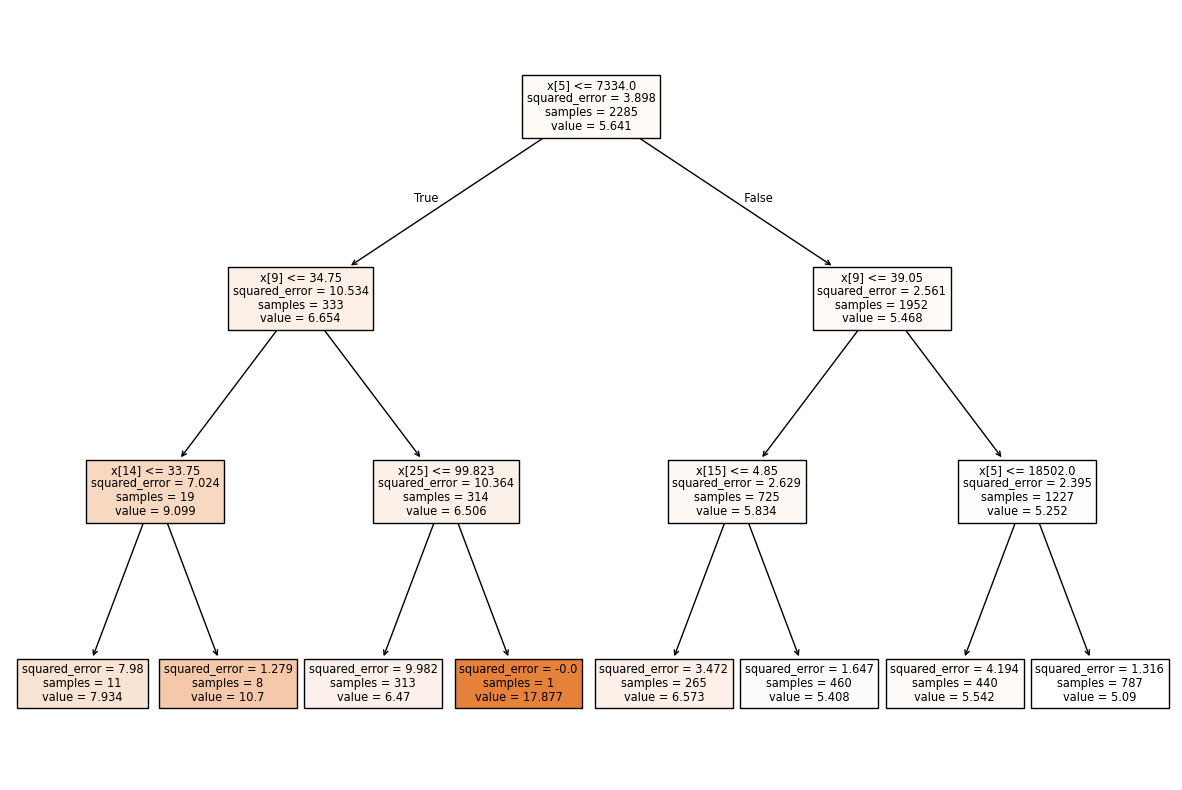

In [57]:
from sklearn.tree import plot_tree
best_model = grid.best_estimator_
plt.figure(figsize=(15,10))
plot_tree(best_model, filled=True)
plt.show()